In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

driver = PySCFDriver(
    atom=(
        "C -0.6672  0.0000  0.0000; "
        "C  0.6672  0.0000  0.0000; "
        "H -1.2213 -0.9290  0.0708; "
        "H -1.2212  0.9290 -0.0708; "
        "H  1.2213  0.0708  0.9290; "
        "H  1.2213 -0.0708 -0.9290"
    ),
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)

problem = driver.run()

print(problem)

In [2]:
print("Number of spatial orbitals:",
      problem.num_spatial_orbitals)

print("Number of particles:",
      problem.num_particles)

print("Number of alpha electrons:",
      problem.num_alpha)

print("Number of beta electrons:",
      problem.num_beta)

Number of spatial orbitals: 14
Number of particles: (8, 8)
Number of alpha electrons: 8
Number of beta electrons: 8


In [3]:
from pyscf import gto, scf
from pyscf.tools import cubegen
import numpy as np


# ============================================================
# 1. 90-degree twisted ethylene (C2H4)
# ============================================================

mol = gto.M(
    atom="""
    C    0.000000    0.000000     0.667200
    C    0.000000    0.000000    -0.667200

    H    0.000000    0.929000     1.221300
    H    0.000000   -0.929000     1.221300

    H    0.929000    0.000000    -1.221300
    H   -0.929000    0.000000    -1.221300
    """,
    basis="sto-3g",
    charge=0,
    spin=0,
    unit="Angstrom"
)


# ============================================================
# 2. RHF calculation
# ============================================================

mf = scf.RHF(mol)

scf_energy = mf.kernel()

print("=" * 60)
print("RHF CALCULATION")
print("=" * 60)

print(f"SCF Energy = {scf_energy:.10f} Hartree")


# ============================================================
# 3. Print all molecular orbitals
# ============================================================

print("\n" + "=" * 60)
print("MO ENERGIES AND OCCUPATIONS")
print("=" * 60)

for i, energy in enumerate(mf.mo_energy):

    occupation = mf.mo_occ[i]

    if occupation > 0:
        status = "Occupied"
    else:
        status = "Virtual"

    print(
        f"MO {i:2d} | "
        f"Energy = {energy: .8f} Ha | "
        f"Occupation = {occupation:.0f} | "
        f"{status}"
    )


# ============================================================
# 4. Identify HOMO and LUMO
# ============================================================

occupied = np.where(mf.mo_occ > 0)[0]
virtual = np.where(mf.mo_occ == 0)[0]

homo = occupied[-1]
lumo = virtual[0]

print("\n" + "=" * 60)
print("HOMO / LUMO")
print("=" * 60)

print(f"HOMO = MO {homo}")
print(f"HOMO Energy = {mf.mo_energy[homo]:.8f} Ha")

print(f"\nLUMO = MO {lumo}")
print(f"LUMO Energy = {mf.mo_energy[lumo]:.8f} Ha")

print(
    f"\nHOMO-LUMO gap = "
    f"{mf.mo_energy[lumo] - mf.mo_energy[homo]:.8f} Ha"
)


# ============================================================
# 5. Generate cube files
# ============================================================

cubegen.orbital(
    mol,
    "ethylene_twisted_HOMO.cube",
    mf.mo_coeff[:, homo]
)

cubegen.orbital(
    mol,
    "ethylene_twisted_LUMO.cube",
    mf.mo_coeff[:, lumo]
)

print("\n" + "=" * 60)
print("ORBITAL FILES")
print("=" * 60)

print("Generated:")
print("  ethylene_twisted_HOMO.cube")
print("  ethylene_twisted_LUMO.cube")


# ============================================================
# 6. Orbital information
# ============================================================

print("\n" + "=" * 60)
print("HOMO / LUMO ORBITAL INFORMATION")
print("=" * 60)

print(f"HOMO orbital index : {homo}")
print(f"LUMO orbital index : {lumo}")

converged SCF energy = -76.8537995673522
RHF CALCULATION
SCF Energy = -76.8537995674 Hartree

MO ENERGIES AND OCCUPATIONS
MO  0 | Energy = -10.99687334 Ha | Occupation = 2 | Occupied
MO  1 | Energy = -10.99627497 Ha | Occupation = 2 | Occupied
MO  2 | Energy = -0.96804669 Ha | Occupation = 2 | Occupied
MO  3 | Energy = -0.73780510 Ha | Occupation = 2 | Occupied
MO  4 | Energy = -0.55479293 Ha | Occupation = 2 | Occupied
MO  5 | Energy = -0.54196543 Ha | Occupation = 2 | Occupied
MO  6 | Energy = -0.52114370 Ha | Occupation = 2 | Occupied
MO  7 | Energy = -0.17672522 Ha | Occupation = 2 | Occupied
MO  8 | Energy =  0.16681944 Ha | Occupation = 0 | Virtual
MO  9 | Energy =  0.67721911 Ha | Occupation = 0 | Virtual
MO 10 | Energy =  0.71460985 Ha | Occupation = 0 | Virtual
MO 11 | Energy =  0.81400240 Ha | Occupation = 0 | Virtual
MO 12 | Energy =  0.82387993 Ha | Occupation = 0 | Virtual
MO 13 | Energy =  0.98748349 Ha | Occupation = 0 | Virtual

HOMO / LUMO
HOMO = MO 7
HOMO Energy = -0.

In [4]:
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# ============================================================
# CAS(2,4)
# ============================================================

num_active_electrons = 2
num_active_orbitals = 4


# ============================================================
# Generate active orbitals
# ============================================================
#
# We need:
#
#   1 occupied spatial orbital
#   3 virtual spatial orbitals
#
# The occupied orbital is the HOMO.
# The virtual orbitals are the three lowest virtual MOs.
#
# This gives CAS(2,4).
# ============================================================

occupied_mos = np.where(mf.mo_occ > 0)[0]
virtual_mos = np.where(mf.mo_occ == 0)[0]

active_mo_indices = np.concatenate([
    occupied_mos[-1:],
    virtual_mos[:3]
]).tolist()


print("=" * 60)
print("GENERATED ACTIVE ORBITALS")
print("=" * 60)

print("HOMO:",
      occupied_mos[-1])

print("Lowest virtual MOs:",
      virtual_mos[:3])

print("\nGenerated active MOs:",
      active_mo_indices)


print("\nActive orbital energies:")

for i in active_mo_indices:

    print(
        f"MO {i}: "
        f"Energy = {mf.mo_energy[i]:.8f} Ha | "
        f"Occupation = {mf.mo_occ[i]:.0f}"
    )


# ============================================================
# Active-space transformation
# ============================================================

active_space_transformer = ActiveSpaceTransformer(
    num_electrons=num_active_electrons,
    num_spatial_orbitals=num_active_orbitals,
    active_orbitals=active_mo_indices
)

active_problem = active_space_transformer.transform(
    problem
)

print("\n" + "=" * 60)
print("ACTIVE SPACE")
print("=" * 60)

print(
    "Active spatial orbitals:",
    active_problem.num_spatial_orbitals
)

print(
    "Active particles:",
    active_problem.num_particles
)

GENERATED ACTIVE ORBITALS
HOMO: 7
Lowest virtual MOs: [ 8  9 10]

Generated active MOs: [7, 8, 9, 10]

Active orbital energies:
MO 7: Energy = -0.17672522 Ha | Occupation = 2
MO 8: Energy = 0.16681944 Ha | Occupation = 0
MO 9: Energy = 0.67721911 Ha | Occupation = 0
MO 10: Energy = 0.71460985 Ha | Occupation = 0

ACTIVE SPACE
Active spatial orbitals: 4
Active particles: (1, 1)


In [5]:
fermionic_op = active_problem.hamiltonian.second_q_op()

print(fermionic_op)

Fermionic Operator
number spin orbitals=8, number terms=528
  -0.7092332585539494 * ( +_0 -_0 )
+ 0.08703364914241948 * ( +_0 -_3 )
+ -0.5842594373240484 * ( +_1 -_1 )
+ 9.953242959742625e-07 * ( +_1 -_2 )
+ 9.953242959544454e-07 * ( +_2 -_1 )
+ 0.03309723151987343 * ( +_2 -_2 )
+ 0.08703364914241926 * ( +_3 -_0 )
+ 0.0668202092866208 * ( +_3 -_3 )
+ -0.7092332585539503 * ( +_4 -_4 )
+ 0.08703364914241948 * ( +_4 -_7 )
+ -0.5842594373240493 * ( +_5 -_5 )
+ 9.953242959742625e-07 * ( +_5 -_6 )
+ 9.953242959544454e-07 * ( +_6 -_5 )
+ 0.03309723151987343 * ( +_6 -_6 )
+ 0.08703364914241926 * ( +_7 -_4 )
+ 0.06682020928661991 * ( +_7 -_7 )
+ 0.29594900469845054 * ( +_0 +_0 -_0 -_0 )
+ -0.043516833707226726 * ( +_0 +_0 -_3 -_0 )
+ 0.1745087008382922 * ( +_0 +_1 -_1 -_0 )
+ -2.043110883035685e-07 * ( +_0 +_1 -_2 -_0 )
+ -2.043110883035685e-07 * ( +_0 +_2 -_1 -_0 )
+ 0.14579078053797506 * ( +_0 +_2 -_2 -_0 )
+ -0.043516833707226726 * ( +_0 +_3 -_0 -_0 )
+ 0.17527673078569941 * ( +_0 +_3 -_3 -_

In [6]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

qubit_hamiltonian = mapper.map(
    fermionic_op
)

print(qubit_hamiltonian)

print(
    "Number of qubits:",
    qubit_hamiltonian.num_qubits
)

SparsePauliOp(['IIIIIIII', 'IIIIIIIZ', 'IIIIYZZY', 'IIIIXZZX', 'IIIIIIZI', 'IIIIIYYI', 'IIIIIXXI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'YZZYIIII', 'XZZXIIII', 'IIZIIIII', 'IYYIIIII', 'IXXIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIYYZ', 'IIIIIXXZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'YZZYIIIZ', 'XZZXIIIZ', 'IIZIIIIZ', 'IYYIIIIZ', 'IXXIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIYZIY', 'IIIIXZIX', 'IIIIYYYY', 'IIIIYXXY', 'IIIIXYYX', 'IIIIXXXX', 'IIYYIIYY', 'IIXXIIYY', 'IIYYIIXX', 'IIXXIIXX', 'YZYIIIYY', 'XZXIIIYY', 'YZYIIIXX', 'XZXIIIXX', 'YYIIIIYY', 'XXIIIIYY', 'YYIIIIXX', 'XXIIIIXX', 'IIIIYIZY', 'IIIIXIZX', 'IYZYIYZY', 'IXZXIYZY', 'IYZYIXZX', 'IXZXIXZX', 'YZYIIYZY', 'XZXIIYZY', 'YZYIIXZX', 'XZXIIXZX', 'YYIIIYZY', 'XXIIIYZY', 'YYIIIXZX', 'XXIIIXZX', 'IIIZYZZY', 'IIIZXZZX', 'YZZYYZZY', 'XZZXYZZY', 'YZZYXZZX', 'XZZXXZZX', 'IIZIYZZY', 'IIZIXZZX', 'IZIIYZZY', 'IZIIXZZX', 'ZIIIYZZY', 'ZIIIXZZX', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'YZZYIIZI', 'XZZXIIZI', 'IIZIIIZI', 'IYYIIIZI', 'IXXIIIZI', '

In [7]:
from qiskit_nature.second_q.circuit.library import HartreeFock

num_spatial_orbitals = (
    active_problem.num_spatial_orbitals
)

num_particles = (
    active_problem.num_particles
)

print(
    "Active spatial orbitals:",
    num_spatial_orbitals
)

print(
    "Active particles:",
    num_particles
)

initial_state = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper
)

print(initial_state)

Active spatial orbitals: 4
Active particles: (1, 1)
     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
          
q_2: ─────
          
q_3: ─────
     ┌───┐
q_4: ┤ X ├
     └───┘
q_5: ─────
          
q_6: ─────
          
q_7: ─────
          


Number of ansatz parameters: 15


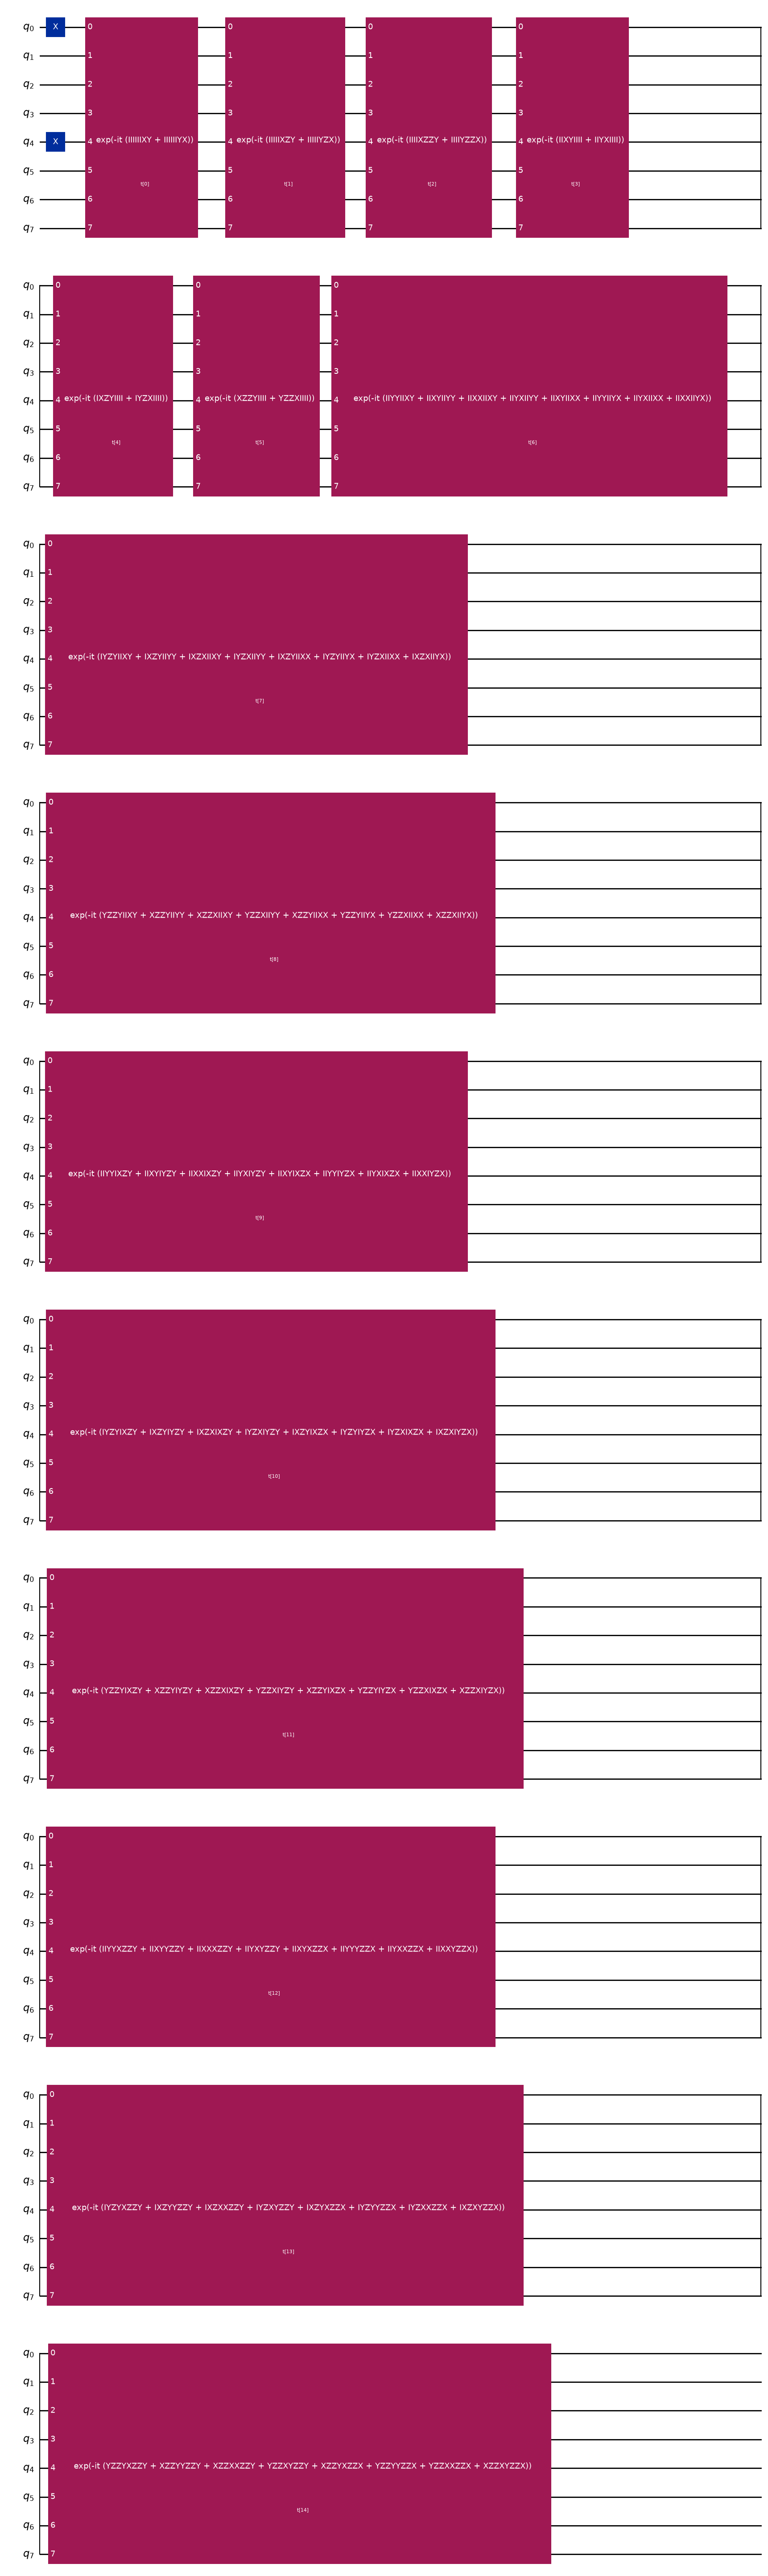

In [8]:
from qiskit_nature.second_q.circuit.library import UCC

ansatz = UCC(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    excitations="sd",
    initial_state=initial_state
)

print(
    "Number of ansatz parameters:",
    ansatz.num_parameters
)

ansatz.decompose().draw("mpl")

In [9]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B

energy_history = []


def callback(eval_count, params, energy, metadata):
    energy_history.append(energy)


estimator = StatevectorEstimator()

optimizer = L_BFGS_B(
    maxiter=500,
    ftol=1e-12
)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

result = vqe.compute_minimum_eigenvalue(
    operator=qubit_hamiltonian
)

vqe_energy = result.eigenvalue.real

print("VQE Ground-State Energy:", vqe_energy)


/home/mohamed/vqe-env/lib/python3.14/site-packages/qiskit_algorithms/optimizers/scipy_optimizer.py:162: OptimizeWarning: Unknown solver options: iprint
  raw_result = minimize(
/home/mohamed/vqe-env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/mohamed/vqe-env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE Ground-State Energy: -0.9542505609042286


In [10]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact_solver = NumPyMinimumEigensolver()

exact_result = (
    exact_solver.compute_minimum_eigenvalue(
        qubit_hamiltonian
    )
)

exact_energy = exact_result.eigenvalue.real

vqe_error = abs(
    vqe_energy - exact_energy
)

print(
    "VQE Ground-State Energy:",
    vqe_energy
)

print(
    "Exact Active-Space Energy:",
    exact_energy
)

print(
    "VQE Error:",
    vqe_error
)

VQE Ground-State Energy: -0.9542505609042286
Exact Active-Space Energy: -0.955960640051354
VQE Error: 0.0017100791471253984


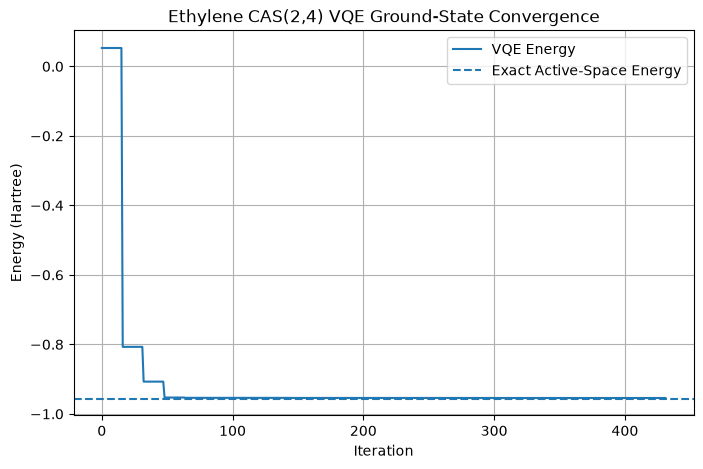

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    energy_history,
    label="VQE Energy"
)

plt.axhline(
    exact_energy,
    linestyle="--",
    label="Exact Active-Space Energy"
)

plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")

plt.title(
    "Ethylene CAS(2,4) VQE Ground-State Convergence"
)

plt.legend()
plt.grid()

plt.show()

In [12]:
# ============================================================
# VQE OPTIMIZED GROUND STATE
# ============================================================

# The VQE result contains the optimized circuit parameters.
optimal_params = result.optimal_point

# Bind the optimized parameters to the ansatz
optimized_circuit = ansatz.assign_parameters(
    optimal_params
)

# Convert the optimized circuit to a statevector
from qiskit.quantum_info import Statevector

vqe_state = Statevector.from_instruction(
    optimized_circuit
)

print("=" * 60)
print("VQE GROUND STATE")
print("=" * 60)

print("Number of qubits:", vqe_state.num_qubits)
print("Statevector dimension:", len(vqe_state.data))

VQE GROUND STATE
Number of qubits: 8
Statevector dimension: 256


In [13]:
import numpy as np
from scipy.linalg import eigh

from qiskit_nature.second_q.operators import FermionicOp


# ============================================================
# QSE — CAS(2,4) SINGLET
# 6 singlet-adapted single-excitation operators
# ============================================================

n_spatial_orbitals = 4
n_spin_orbitals = 2 * n_spatial_orbitals

qse_fermionic_ops = []


# ------------------------------------------------------------
# Operator 0 = Identity
# ------------------------------------------------------------

qse_fermionic_ops.append(
    FermionicOp(
        {"": 1.0},
        num_spin_orbitals=n_spin_orbitals
    )
)


# ------------------------------------------------------------
# Singlet-adapted single excitations
#
# E_ai =
# a†(a,alpha) a(i,alpha)
# +
# a†(a,beta)  a(i,beta)
#
# Selected spatial orbital pairs:
#
# 0 -> 1
# 0 -> 2
# 0 -> 3
# 1 -> 2
# 1 -> 3
# ------------------------------------------------------------

excitation_pairs = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 3),
]


for i, a in excitation_pairs:

    alpha_create = 2 * a
    alpha_annihilate = 2 * i

    beta_create = 2 * a + 1
    beta_annihilate = 2 * i + 1

    op = FermionicOp(
        {
            f"+_{alpha_create} -_{alpha_annihilate}": 1.0,
            f"+_{beta_create} -_{beta_annihilate}": 1.0,
        },
        num_spin_orbitals=n_spin_orbitals
    )

    qse_fermionic_ops.append(op)


# ============================================================
# Print QSE subspace
# ============================================================

print("=" * 60)
print("QSE SUBSPACE — CAS(2,4) SINGLET")
print("=" * 60)

print("Number of QSE operators:", len(qse_fermionic_ops))

for k, op in enumerate(qse_fermionic_ops):
    print(f"\nOperator {k}:")
    print(op)

QSE SUBSPACE — CAS(2,4) SINGLET
Number of QSE operators: 6

Operator 0:
Fermionic Operator
number spin orbitals=8, number terms=1
  1.0

Operator 1:
Fermionic Operator
number spin orbitals=8, number terms=2
  1.0 * ( +_2 -_0 )
+ 1.0 * ( +_3 -_1 )

Operator 2:
Fermionic Operator
number spin orbitals=8, number terms=2
  1.0 * ( +_4 -_0 )
+ 1.0 * ( +_5 -_1 )

Operator 3:
Fermionic Operator
number spin orbitals=8, number terms=2
  1.0 * ( +_6 -_0 )
+ 1.0 * ( +_7 -_1 )

Operator 4:
Fermionic Operator
number spin orbitals=8, number terms=2
  1.0 * ( +_4 -_2 )
+ 1.0 * ( +_5 -_3 )

Operator 5:
Fermionic Operator
number spin orbitals=8, number terms=2
  1.0 * ( +_6 -_2 )
+ 1.0 * ( +_7 -_3 )


In [14]:
# ============================================================
# MAP QSE OPERATORS TO QUBITS
# ============================================================

qse_qubit_ops = [
    mapper.map(op)
    for op in qse_fermionic_ops
]

print("=" * 60)
print("QSE QUBIT OPERATORS")
print("=" * 60)

for i, op in enumerate(qse_qubit_ops):

    print(f"\nOperator {i}:")
    print(op)

QSE QUBIT OPERATORS

Operator 0:
SparsePauliOp(['IIIIIIII'],
              coeffs=[1.+0.j])

Operator 1:
SparsePauliOp(['IIIIIXZY', 'IIIIIXZX', 'IIIIIYZY', 'IIIIIYZX', 'IIIIXZYI', 'IIIIXZXI', 'IIIIYZYI', 'IIIIYZXI'],
              coeffs=[0.  +0.25j, 0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  +0.25j, 0.25+0.j  ,
 0.25+0.j  , 0.  -0.25j])

Operator 2:
SparsePauliOp(['IIIXZZZY', 'IIIXZZZX', 'IIIYZZZY', 'IIIYZZZX', 'IIXZZZYI', 'IIXZZZXI', 'IIYZZZYI', 'IIYZZZXI'],
              coeffs=[0.  +0.25j, 0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  +0.25j, 0.25+0.j  ,
 0.25+0.j  , 0.  -0.25j])

Operator 3:
SparsePauliOp(['IXZZZZZY', 'IXZZZZZX', 'IYZZZZZY', 'IYZZZZZX', 'XZZZZZYI', 'XZZZZZXI', 'YZZZZZYI', 'YZZZZZXI'],
              coeffs=[0.  +0.25j, 0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  +0.25j, 0.25+0.j  ,
 0.25+0.j  , 0.  -0.25j])

Operator 4:
SparsePauliOp(['IIIXZYII', 'IIIXZXII', 'IIIYZYII', 'IIIYZXII', 'IIXZYIII', 'IIXZXIII', 'IIYZYIII', 'IIYZXIII'],
              coeffs=[0.  +0.25j, 0.25+0.j  , 0.

In [15]:
# ============================================================
# CONSTRUCT QSE SUBSPACE STATES
# ============================================================

import numpy as np
from qiskit.quantum_info import SparsePauliOp

qse_states = []

for op in qse_qubit_ops:

    # Convert operator to matrix
    matrix = op.to_matrix()

    # Apply operator to VQE state
    state = matrix @ vqe_state.data

    qse_states.append(state)


print("=" * 60)
print("QSE STATES")
print("=" * 60)

print(
    "Number of subspace states:",
    len(qse_states)
)

QSE STATES
Number of subspace states: 6


In [16]:
# ============================================================
# QSE HAMILTONIAN AND OVERLAP MATRICES
# ============================================================

H_matrix = qubit_hamiltonian.to_matrix()

n_qse = len(qse_states)

H_qse = np.zeros(
    (n_qse, n_qse),
    dtype=complex
)

S_qse = np.zeros(
    (n_qse, n_qse),
    dtype=complex
)


# ------------------------------------------------------------
# Build H and S
# ------------------------------------------------------------

for i in range(n_qse):

    for j in range(n_qse):

        bra_i = np.conjugate(qse_states[i])

        ket_j = qse_states[j]

        # H_ij = <Phi_i | H | Phi_j>
        H_qse[i, j] = (
            bra_i @ H_matrix @ ket_j
        )

        # S_ij = <Phi_i | Phi_j>
        S_qse[i, j] = (
            bra_i @ ket_j
        )


# Remove tiny numerical imaginary parts
H_qse = np.real_if_close(H_qse)

S_qse = np.real_if_close(S_qse)


print("=" * 60)
print("QSE MATRICES")
print("=" * 60)

print("\nH matrix:")
print(np.round(H_qse, 8))

print("\nOverlap matrix S:")
print(np.round(S_qse, 8))

QSE MATRICES

H matrix:
[[-9.5425056e-01 -1.0170000e-05  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-1.0170000e-05 -9.5865130e-02  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00 -9.3604525e-01 -1.2920000e-05
  -3.5300000e-05 -9.6554000e-03]
 [ 0.0000000e+00  0.0000000e+00 -1.2920000e-05 -1.3868391e-01
   5.1000000e-07 -5.2800000e-06]
 [ 0.0000000e+00  0.0000000e+00 -3.5300000e-05  5.1000000e-07
  -0.0000000e+00 -3.5000000e-07]
 [ 0.0000000e+00  0.0000000e+00 -9.6554000e-03 -5.2800000e-06
  -3.5000000e-07 -6.0253000e-04]]

Overlap matrix S:
[[ 1.0000000e+00  4.0020000e-05  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 4.0020000e-05  9.8943294e-01  0.0000000e+00  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  9.8943294e-01  6.6080000e-05
   3.7510000e-05  2.7000000e-07]
 [ 0.0000000e+00  0.0000000e+00  6.6080000e-05  9.8943294e-01
  -3.6100000e-06  4.0020000e-05]
 [ 0.0

In [17]:
# ============================================================
# ROBUST QSE SOLUTION
# ============================================================

from scipy.linalg import eigh

# Symmetrize
H_qse = (H_qse + H_qse.T.conj()) / 2
S_qse = (S_qse + S_qse.T.conj()) / 2


# ------------------------------------------------------------
# Diagonalize overlap matrix
# ------------------------------------------------------------

s_values, s_vectors = eigh(S_qse)

print("=" * 60)
print("QSE OVERLAP EIGENVALUES")
print("=" * 60)

for i, value in enumerate(s_values):
    print(f"{i}: {value:.12e}")


# ------------------------------------------------------------
# Remove linearly dependent directions
# ------------------------------------------------------------

threshold = 1e-8

keep = s_values > threshold

print("\nKeeping",
      np.sum(keep),
      "out of",
      len(s_values),
      "QSE basis states")


S_inv_sqrt = (
    s_vectors[:, keep]
    @ np.diag(1.0 / np.sqrt(s_values[keep]))
)


# ------------------------------------------------------------
# Transform generalized eigenvalue problem
#
# H C = E S C
#
# into ordinary eigenvalue problem
#
# H_tilde C_tilde = E C_tilde
# ------------------------------------------------------------

H_transformed = (
    S_inv_sqrt.conj().T
    @ H_qse
    @ S_inv_sqrt
)

H_transformed = (
    H_transformed
    + H_transformed.T.conj()
) / 2


qse_energies, qse_vectors = eigh(
    H_transformed
)

qse_energies = np.real(qse_energies)


print("\n" + "=" * 60)
print("QSE ENERGIES")
print("=" * 60)

for i, energy in enumerate(qse_energies):

    excitation_energy = (
        energy - qse_energies[0]
    )

    print(
        f"State {i}: "
        f"Energy = {energy:.10f} Ha | "
        f"Excitation = {excitation_energy:.10f} Ha"
    )

QSE OVERLAP EIGENVALUES
0: 4.651104057452e-09
1: 1.056705827893e-02
2: 9.893668575261e-01
3: 9.894327872293e-01
4: 9.894990219329e-01
5: 1.000000151544e+00

Keeping 5 out of 6 QSE basis states

QSE ENERGIES
State 0: Energy = -0.9559606350 Ha | Excitation = 0.0000000000 Ha
State 1: Energy = -0.9542505618 Ha | Excitation = 0.0017100732 Ha
State 2: Energy = -0.1401650410 Ha | Excitation = 0.8157955940 Ha
State 3: Energy = -0.0968889628 Ha | Excitation = 0.8590716722 Ha
State 4: Energy = -0.0471003782 Ha | Excitation = 0.9088602568 Ha


In [18]:
# ============================================================
# CLASSICAL CASCI BENCHMARK
# Twisted Ethylene (90 degrees)
# CAS(2,4) — Singlet
# ============================================================

import numpy as np
from pyscf import gto, scf, mcscf

HARTREE_TO_EV = 27.211386245988


# ============================================================
# 1. MOLECULAR GEOMETRY
# ============================================================

mol = gto.M(
    atom="""
    C    0.000000    0.000000     0.667200
    C    0.000000    0.000000    -0.667200

    H    0.000000    0.929000     1.221300
    H    0.000000   -0.929000     1.221300

    H    0.929000    0.000000    -1.221300
    H   -0.929000    0.000000    -1.221300
    """,
    basis="sto-3g",
    charge=0,
    spin=0,
    unit="Angstrom"
)

print("=" * 70)
print("TWISTED ETHYLENE — 90°")
print("=" * 70)

print(f"Number of electrons : {mol.nelectron}")
print(f"Number of AOs       : {mol.nao_nr()}")


# ============================================================
# 2. RHF
# ============================================================

mf = scf.RHF(mol)

scf_energy = mf.kernel()

print("\n" + "=" * 70)
print("RHF")
print("=" * 70)

print(f"RHF Energy = {scf_energy:.10f} Ha")


# ============================================================
# 3. PRINT MO ENERGIES
# ============================================================

print("\n" + "=" * 70)
print("MO ENERGIES")
print("=" * 70)

for i, (energy, occ) in enumerate(zip(mf.mo_energy, mf.mo_occ)):

    if occ > 0:
        status = "Occupied"
    else:
        status = "Virtual"

    print(
        f"MO {i:2d} | "
        f"Energy = {energy: .10f} Ha | "
        f"Occupation = {int(occ)} | "
        f"{status}"
    )


# ============================================================
# 4. DEFINE CAS(2,4)
# ============================================================
#
# Ethylene has 16 electrons.
#
# CAS(2,4):
#   2 active electrons
#   4 active spatial orbitals
#
# Therefore:
#
#   (16 - 2) / 2 = 7 doubly occupied core orbitals
#
# Active orbitals:
#
#   MO 7
#   MO 8
#   MO 9
#   MO 10
#
# ============================================================

ncas = 4
nelecas = 2

ncore = (mol.nelectron - nelecas) // 2

active_orbitals = list(
    range(ncore, ncore + ncas)
)

print("\n" + "=" * 70)
print("ACTIVE SPACE")
print("=" * 70)

print(f"Total electrons       : {mol.nelectron}")
print(f"Core orbitals         : {ncore}")
print(f"Active electrons      : {nelecas}")
print(f"Active spatial orbitals: {ncas}")

print(f"\nActive MO indices     : {active_orbitals}")

for i in active_orbitals:
    print(
        f"MO {i:2d} | "
        f"Energy = {mf.mo_energy[i]: .10f} Ha"
    )


# ============================================================
# 5. CASCI
# ============================================================

mc = mcscf.CASCI(
    mf,
    ncas=ncas,
    nelecas=nelecas
)

# Freeze the 7 core orbitals
mc.ncore = ncore

# Calculate several singlet states
mc.fcisolver.nroots = 4
mc.fcisolver.spin = 0

# IMPORTANT:
# Pass the COMPLETE RHF MO coefficient matrix.
#
# PySCF uses:
#   ncore = 7
#   ncas  = 4
#   nelecas = 2
#
# to construct CAS(2,4).
#
mc.kernel(mf.mo_coeff)


# ============================================================
# 6. CASCI TOTAL ENERGIES
# ============================================================

casci_energies = np.asarray(mc.e_tot).real

print("\n" + "=" * 70)
print("CASCI TOTAL ENERGIES — CAS(2,4)")
print("=" * 70)

for i, energy in enumerate(casci_energies):

    print(
        f"State {i} : "
        f"{energy:.10f} Ha"
    )


# ============================================================
# 7. EXCITATION ENERGIES
# ============================================================

ground_energy = casci_energies[0]

print("\n" + "=" * 70)
print("CASCI EXCITATION ENERGIES")
print("=" * 70)

for i in range(1, len(casci_energies)):

    excitation_hartree = (
        casci_energies[i] - ground_energy
    )

    excitation_ev = (
        excitation_hartree * HARTREE_TO_EV
    )

    print(
        f"State {i}: "
        f"{excitation_hartree:.10f} Ha = "
        f"{excitation_ev:.6f} eV"
    )


# ============================================================
# 8. SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLASSICAL BENCHMARK")
print("=" * 70)

print(f"CAS         : CAS({nelecas},{ncas})")
print(f"Core        : {ncore} doubly occupied orbitals")
print(f"Active MOs  : {active_orbitals}")
print(f"Spin        : Singlet (S = 0)")

print(
    f"\nGround state energy : "
    f"{casci_energies[0]:.10f} Ha"
)

for i in range(1, len(casci_energies)):

    delta = casci_energies[i] - ground_energy

    print(
        f"Excited state {i}    : "
        f"{casci_energies[i]:.10f} Ha"
    )

    print(
        f"Excitation {i}       : "
        f"{delta:.10f} Ha = "
        f"{delta * HARTREE_TO_EV:.6f} eV"
    )

print("=" * 70)

TWISTED ETHYLENE — 90°
Number of electrons : 16
Number of AOs       : 14
converged SCF energy = -76.8537995673472

RHF
RHF Energy = -76.8537995673 Ha

MO ENERGIES
MO  0 | Energy = -10.9968730468 Ha | Occupation = 2 | Occupied
MO  1 | Energy = -10.9962747015 Ha | Occupation = 2 | Occupied
MO  2 | Energy = -0.9680465912 Ha | Occupation = 2 | Occupied
MO  3 | Energy = -0.7378050617 Ha | Occupation = 2 | Occupied
MO  4 | Energy = -0.5547927345 Ha | Occupation = 2 | Occupied
MO  5 | Energy = -0.5419656089 Ha | Occupation = 2 | Occupied
MO  6 | Energy = -0.5211436092 Ha | Occupation = 2 | Occupied
MO  7 | Energy = -0.1767249569 Ha | Occupation = 2 | Occupied
MO  8 | Energy =  0.1668197223 Ha | Occupation = 0 | Virtual
MO  9 | Energy =  0.6772192210 Ha | Occupation = 0 | Virtual
MO 10 | Energy =  0.7146099632 Ha | Occupation = 0 | Virtual
MO 11 | Energy =  0.8140024630 Ha | Occupation = 0 | Virtual
MO 12 | Energy =  0.8238799323 Ha | Occupation = 0 | Virtual
MO 13 | Energy =  0.9874835842 Ha 

In [19]:
HA_TO_EV = 27.211386245988

# State 1 excitation energy
casci_exc_1 = casci_energies[1] - casci_energies[0]
qse_exc_1 = qse_energies[1] - qse_energies[0]

# Absolute error
error_ha = abs(qse_exc_1 - casci_exc_1)
error_ev = error_ha * HA_TO_EV

# Percentage error
percentage_error = (error_ha / abs(casci_exc_1)) * 100

print("=" * 50)
print("STATE 1 QSE vs CASCI ERROR")
print("=" * 50)
print(f"CASCI excitation = {casci_exc_1:.10f} Ha")
print(f"QSE excitation   = {qse_exc_1:.10f} Ha")
print(f"Error            = {error_ha:.10f} Ha")
print(f"Error            = {error_ev:.6f} eV")
print(f"Percentage Error = {percentage_error:.2f}%")

STATE 1 QSE vs CASCI ERROR
CASCI excitation = 0.0026051519 Ha
QSE excitation   = 0.0017100732 Ha
Error            = 0.0008950787 Ha
Error            = 0.024356 eV
Percentage Error = 34.36%


HARDWARE-EFFICIENT ANSATZ
Number of qubits: 8
Number of HE ansatz parameters: 64
HE ansatz depth: 20
UCCSD ansatz parameters: 15
UCCSD ansatz depth: 965


/tmp/ipykernel_687253/386524242.py:10: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  he_circuit = EfficientSU2(


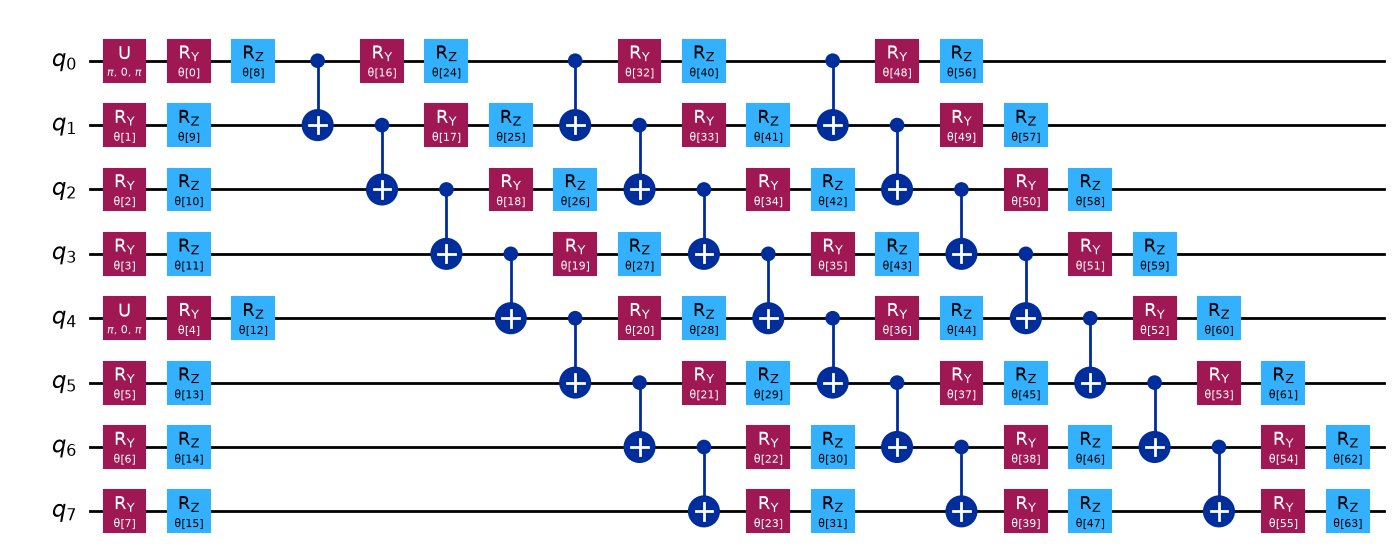

In [20]:
from qiskit.circuit.library import EfficientSU2

# ============================================================
# HARDWARE-EFFICIENT ANSATZ
# Twisted Ethylene 90° — CAS(2,4)
# ============================================================

num_qubits = qubit_hamiltonian.num_qubits

he_circuit = EfficientSU2(
    num_qubits=num_qubits,
    reps=3,
    entanglement="linear"
)

# Start from Hartree-Fock state
he_ansatz = initial_state.compose(he_circuit)

print("=" * 60)
print("HARDWARE-EFFICIENT ANSATZ")
print("=" * 60)

print("Number of qubits:", num_qubits)
print("Number of HE ansatz parameters:", he_ansatz.num_parameters)
print("HE ansatz depth:", he_ansatz.decompose().depth())

print("UCCSD ansatz parameters:", ansatz.num_parameters)
print(
    "UCCSD ansatz depth:",
    ansatz.decompose().decompose().depth()
)

# Draw circuit
he_ansatz.decompose().draw("mpl")

In [21]:
# ============================================================
# HARDWARE-EFFICIENT VQE
# Twisted Ethylene 90° — CAS(2,4)
# ============================================================

from qiskit_algorithms.optimizers import SPSA
import numpy as np

he_energy_history = []
he_params_history = []


def he_callback(eval_count, params, energy, metadata):
    he_energy_history.append(energy)
    he_params_history.append(params)


# ============================================================
# SPSA OPTIMIZER
# ============================================================

he_optimizer = SPSA(
    maxiter=2000
)


# ============================================================
# INITIAL PARAMETERS
# Start close to the Hartree-Fock state
# ============================================================

he_initial_point = np.zeros(
    he_ansatz.num_parameters
)


# ============================================================
# VQE
# ============================================================

he_vqe = VQE(
    estimator=estimator,
    ansatz=he_ansatz,
    optimizer=he_optimizer,
    initial_point=he_initial_point,
    callback=he_callback
)


# ============================================================
# RUN VQE
# ============================================================

he_result = he_vqe.compute_minimum_eigenvalue(
    operator=qubit_hamiltonian
)

he_vqe_energy = he_result.eigenvalue.real


# ============================================================
# RESULTS
# ============================================================

he_error = abs(
    he_vqe_energy - exact_energy
)

print("=" * 60)
print("HARDWARE-EFFICIENT VQE RESULTS")
print("=" * 60)

print(
    f"Hardware-Efficient VQE Ground-State Energy: "
    f"{he_vqe_energy:.10f} Ha"
)

print(
    f"Exact Active-Space Energy: "
    f"{exact_energy:.10f} Ha"
)

print(
    f"HE VQE Error: "
    f"{he_error:.10f} Ha"
)

HARDWARE-EFFICIENT VQE RESULTS
Hardware-Efficient VQE Ground-State Energy: -0.9452827885 Ha
Exact Active-Space Energy: -0.9559606401 Ha
HE VQE Error: 0.0106778516 Ha


In [22]:
# ============================================================
# CHECK HE-VQE OPTIMAL PARAMETERS
# ============================================================

print(
    "Ansatz expects this many parameters:",
    he_ansatz.num_parameters
)

print(
    "Type of optimal_parameters:",
    type(he_result.optimal_parameters)
)

print(
    "Shape/length of optimal_parameters:",
    np.shape(he_result.optimal_parameters)
)

Ansatz expects this many parameters: 64
Type of optimal_parameters: <class 'dict'>
Shape/length of optimal_parameters: ()


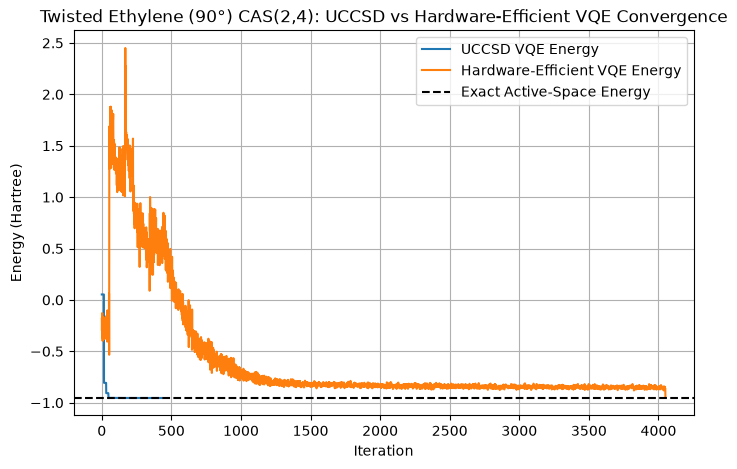

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    energy_history,
    label="UCCSD VQE Energy"
)

plt.plot(
    he_energy_history,
    label="Hardware-Efficient VQE Energy"
)

plt.axhline(
    exact_energy,
    linestyle="--",
    color="black",
    label="Exact Active-Space Energy"
)

plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")

plt.title(
    "Twisted Ethylene (90°) CAS(2,4): "
    "UCCSD vs Hardware-Efficient VQE Convergence"
)

plt.legend()
plt.grid()
plt.show()

In [33]:
from scipy.linalg import eigh
import numpy as np

def regularized_qse_eig(H, S, threshold=1e-8):
    # Symmetrize
    H = (H + H.conj().T) / 2
    S = (S + S.conj().T) / 2

    # Diagonalize overlap matrix
    s_values, s_vectors = eigh(S)

    keep = s_values > threshold
    if not np.any(keep):
        raise ValueError(f"No eigenvalues above threshold={threshold:.0e}")

    S_inv_sqrt = s_vectors[:, keep] @ np.diag(1.0 / np.sqrt(s_values[keep]))

    H_transformed = S_inv_sqrt.conj().T @ H @ S_inv_sqrt
    H_transformed = (H_transformed + H_transformed.conj().T) / 2

    energies, vectors_transformed = eigh(H_transformed)
    # Map eigenvectors back to the original (non-orthogonal) basis
    vectors = S_inv_sqrt @ vectors_transformed

    return np.real(energies), vectors

In [34]:
# ============================================================
# BUILD QSE SUBSPACE FROM HARDWARE-EFFICIENT VQE STATE
# ============================================================
from qiskit.quantum_info import Statevector

he_optimal_params = he_result.optimal_point
he_optimized_circuit = he_ansatz.assign_parameters(he_optimal_params)
he_state = Statevector.from_instruction(he_optimized_circuit)
he_phi0 = he_state.data

# Reuse the same qse_qubit_ops (identity + 5 singlet excitations) from cells 12-13
he_qse_states = [op.to_matrix() @ he_phi0 for op in qse_qubit_ops]

n_qse = len(he_qse_states)
he_H_qse = np.zeros((n_qse, n_qse), dtype=complex)
he_S = np.zeros((n_qse, n_qse), dtype=complex)

for i in range(n_qse):
    for j in range(n_qse):
        bra_i = np.conjugate(he_qse_states[i])
        ket_j = he_qse_states[j]
        he_H_qse[i, j] = bra_i @ H_matrix @ ket_j
        he_S[i, j] = bra_i @ ket_j

he_H_qse = np.real_if_close(he_H_qse)
he_S = np.real_if_close(he_S)

In [35]:
import numpy as np
from scipy.linalg import eigh

# ============================================================
# STEP 1 — TEST: هل الـ small eigenvalue هي فعلاً noise؟
# ============================================================
for thr in [1e-6, 1e-4, 1e-3, 1e-2]:
    try:
        e, v = regularized_qse_eig(he_H_qse, he_S, threshold=thr)
        print(f"threshold={thr:.0e} -> energies: {e}")
    except ValueError as err:
        print(f"threshold={thr:.0e} -> {err}")

threshold=1e-06 -> energies: [-0.94574546 -0.91197586 -0.33462526 -0.28885044 -0.11630885 -0.02953422]
threshold=1e-04 -> energies: [-0.94573721 -0.91183517 -0.33461289 -0.28878552 -0.03541317]
threshold=1e-03 -> energies: [-0.94541541 -0.91149275 -0.33450947 -0.28878301]
threshold=1e-02 -> energies: [-0.94533706 -0.33450951 -0.28878309]


In [36]:
# ============================================================
# STEP 2 — ابنِ subspace أوسع: كل الإثارات الفردية الممكنة
# بدل إثارة واحدة محددة (زي qEOM)
# ============================================================
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

# كل الإثارات الفردية alpha/beta الممكنة من occupied لـ virtual
# (عدّل القائمة دي حسب active space الفعلي بتاعك: occupied vs virtual indices)
excitation_ops_fermionic = {
    "pi_to_pistar_a": FermionicOp({"+_4 -_0": 1.0}, num_spin_orbitals=8),
    "pi_to_pistar_b": FermionicOp({"+_5 -_1": 1.0}, num_spin_orbitals=8),
    "other_1": FermionicOp({"+_6 -_0": 1.0}, num_spin_orbitals=8),
    "other_2": FermionicOp({"+_7 -_1": 1.0}, num_spin_orbitals=8),
    # أضف أي إثارات تانية ذات معنى في CAS(2,4) بتاعك
}

basis_vectors = [he_phi0]
labels = ["ground"]
for name, op in excitation_ops_fermionic.items():
    qop = mapper.map(op)
    vec = qop.to_matrix() @ he_phi0
    norm = np.linalg.norm(vec)
    print(f"{name}: ||vec|| = {norm:.6f}")
    if norm > 1e-8:          # استبعد أي اتجاه صفري فعليًا
        basis_vectors.append(vec)
        labels.append(name)

n = len(basis_vectors)
he_S_full = np.zeros((n, n), dtype=complex)
he_H_full = np.zeros((n, n), dtype=complex)
for i in range(n):
    for j in range(n):
        he_S_full[i, j] = np.vdot(basis_vectors[i], basis_vectors[j])
        he_H_full[i, j] = np.vdot(basis_vectors[i], H_matrix @ basis_vectors[j])

he_qse_energies_full, he_qse_vectors_full = regularized_qse_eig(
    he_H_full, he_S_full, threshold=1e-6
)

print("\nQSE energies from expanded subspace:")
for i, e in enumerate(he_qse_energies_full):
    print(f"State {i}: {e.real:.10f} Ha")

# حدد أي state فيه أعلى "character" من π→π* excitation
# عن طريق حساب overlap بتاع كل eigenvector مع الاتجاه الأصلي
pi_pistar_index = labels.index("pi_to_pistar_a")  # أو اجمع a و b
for i in range(len(he_qse_energies_full)):
    weight = abs(he_qse_vectors_full[pi_pistar_index, i])**2
    print(f"State {i}: π→π* character weight = {weight:.4f}")

pi_to_pistar_a: ||vec|| = 0.000762
pi_to_pistar_b: ||vec|| = 0.268065
other_1: ||vec|| = 0.019949
other_2: ||vec|| = 0.268120

QSE energies from expanded subspace:
State 0: -0.9454174243 Ha
State 1: -0.9114444106 Ha
State 2: -0.3355475223 Ha
State 3: -0.1339049362 Ha
State 0: π→π* character weight = 0.0000
State 1: π→π* character weight = 0.0119
State 2: π→π* character weight = 0.0000
State 3: π→π* character weight = 0.0027


In [37]:
# ============================================================
# NOISE MODEL — generic depolarizing + thermal relaxation + readout
# ============================================================
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError
)

def build_noise_model(num_qubits, t1=50e3, t2=70e3, gate_time_1q=50, gate_time_2q=300,
                       p1=0.001, p2=0.01, readout_err=0.02):
    """t1/t2 in ns, gate times in ns — rough superconducting-qubit numbers."""
    noise_model = NoiseModel()

    # 1-qubit gate error: thermal relaxation + depolarizing
    err_1q = thermal_relaxation_error(t1, t2, gate_time_1q).compose(
        depolarizing_error(p1, 1)
    )
    noise_model.add_all_qubit_quantum_error(err_1q, ["sx", "x", "rz", "u1", "u2", "u3", "ry", "rx"])

    # 2-qubit gate error
    err_2q = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
        thermal_relaxation_error(t1, t2, gate_time_2q)
    ).compose(depolarizing_error(p2, 2))
    noise_model.add_all_qubit_quantum_error(err_2q, ["cx", "cz", "ecr"])

    # Readout error
    ro_error = ReadoutError([[1 - readout_err, readout_err],
                              [readout_err, 1 - readout_err]])
    for q in range(num_qubits):
        noise_model.add_readout_error(ro_error, [q])

    return noise_model

num_qubits = qubit_hamiltonian.num_qubits
noise_model = build_noise_model(num_qubits)

print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'cz', 'ecr', 'id', 'rx', 'ry', 'rz', 'sx', 'u1', 'u2', 'u3', 'x']
  Instructions with noise: ['u3', 'cx', 'u2', 'rz', 'measure', 'rx', 'cz', 'x', 'ecr', 'u1', 'ry', 'sx']
  Qubits with noise: [0, 1, 2, 3, 4, 5, 6, 7]
  All-qubits errors: ['sx', 'x', 'rz', 'u1', 'u2', 'u3', 'ry', 'rx', 'cx', 'cz', 'ecr']
  Specific qubit errors: [('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,)), ('measure', (5,)), ('measure', (6,)), ('measure', (7,))]


In [45]:
from qiskit import transpile

# Decompose fully into basic gates the noisy simulator understands
he_ansatz_decomposed = he_ansatz.decompose(reps=3)

# Safer/more robust: transpile against the actual noisy backend
noisy_backend = AerSimulator(noise_model=noise_model)
he_ansatz_transpiled = transpile(he_ansatz, backend=noisy_backend, optimization_level=1)

In [46]:
import numpy as np
test_circuit = he_ansatz.assign_parameters(np.zeros(he_ansatz.num_parameters))
test_result = noisy_estimator.run([(test_circuit, qubit_hamiltonian)]).result()
print(test_result)

AerError: 'unknown instruction: EfficientSU2'

In [47]:
# ============================================================
# NOISY VQE RUN
# ============================================================
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.optimizers import SPSA

# noisy_estimator = AerEstimator(
#     options={
#         "backend_options": {"noise_model": noise_model},
#         "default_shots": 8192,
#     }
# )

from qiskit import transpile

# Decompose fully into basic gates the noisy simulator understands
he_ansatz_decomposed = he_ansatz.decompose(reps=3)

# Safer/more robust: transpile against the actual noisy backend
noisy_backend = AerSimulator(noise_model=noise_model)
he_ansatz_transpiled = transpile(he_ansatz, backend=noisy_backend, optimization_level=1)

# noisy_estimator = AerEstimator(
#     options={
#         "backend_options": {"noise_model": noise_model},
#         "run_options": {"shots": 8192},
#     }
# )
# noisy_energy_history = []
# def noisy_callback(eval_count, params, energy, metadata):
#     noisy_energy_history.append(energy)

# # Warm-start from the ideal HE-VQE optimum, and use SPSA (robust to shot noise)
# noisy_vqe = VQE(
#     estimator=noisy_estimator,
#     ansatz=he_ansatz,
#     optimizer=SPSA(maxiter=150),
#     initial_point=he_result.optimal_point,
#     callback=noisy_callback,
# )

noisy_vqe = VQE(
    estimator=noisy_estimator,
    ansatz=he_ansatz_transpiled,
    optimizer=SPSA(maxiter=150),
    initial_point=he_result.optimal_point,
    callback=noisy_callback,
)

noisy_result = noisy_vqe.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
noisy_energy = noisy_result.eigenvalue.real
noisy_error = abs(noisy_energy - exact_energy)

print(f"Noisy VQE Energy: {noisy_energy:.10f} Ha")
print(f"Exact Energy:     {exact_energy:.10f} Ha")
print(f"Noisy VQE Error:  {noisy_error:.10f} Ha")

noisy_result = noisy_vqe.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
noisy_energy = noisy_result.eigenvalue.real
noisy_error = abs(noisy_energy - exact_energy)

print(f"Noisy VQE Energy: {noisy_energy:.10f} Ha")
print(f"Exact Energy:     {exact_energy:.10f} Ha")
print(f"Noisy VQE Error:  {noisy_error:.10f} Ha")

Noisy VQE Energy: 1.3046708641 Ha
Exact Energy:     -0.9559606401 Ha
Noisy VQE Error:  2.2606315042 Ha
Noisy VQE Energy: 1.1936907187 Ha
Exact Energy:     -0.9559606401 Ha
Noisy VQE Error:  2.1496513588 Ha


In [49]:
# ============================================================
# ZERO-NOISE EXTRAPOLATION (unitary folding)
# ============================================================
import numpy as np

def fold_circuit(circuit, scale_factor):
    """Global folding: append (scale_factor-1)/2 rounds of U U^-1 U."""
    folded = circuit.copy()
    n_folds = int(round((scale_factor - 1) / 2))
    for _ in range(n_folds):
        folded = folded.compose(circuit.inverse()).compose(circuit)
    return folded

# def zne_expectation(ansatz, params, hamiltonian, estimator, scale_factors=(1, 3, 5)):
#     bound = ansatz.assign_parameters(params)
#     energies = []
#     for s in scale_factors:
#         folded = fold_circuit(bound, s)
#         job = estimator.run([(folded, hamiltonian)])
#         energies.append(job.result()[0].data.evs)
#     # Linear extrapolation back to zero noise (scale_factor -> 0)
#     coeffs = np.polyfit(scale_factors, energies, deg=1)
#     zne_energy = coeffs[-1]  # intercept
# #     return zne_energy, energies
# zne_energy, raw_energies = zne_expectation(
#     he_ansatz, noisy_result.optimal_point, qubit_hamiltonian, noisy_estimator
# )

# print("Raw noisy energies at scale factors (1,3,5):", raw_energies)
# print(f"ZNE-extrapolated energy: {zne_energy:.10f} Ha")
# print(f"ZNE error vs exact:      {abs(zne_energy - exact_energy):.10f} Ha")

def zne_expectation(ansatz, params, hamiltonian, estimator, backend, scale_factors=(1, 3, 5)):
    bound = ansatz.assign_parameters(params)
    energies = []
    for s in scale_factors:
        folded = fold_circuit(bound, s)
        folded_transpiled = transpile(folded, backend=backend, optimization_level=1)
        job = estimator.run([(folded_transpiled, hamiltonian)])
        energies.append(job.result()[0].data.evs)
    coeffs = np.polyfit(scale_factors, energies, deg=1)
    zne_energy = coeffs[-1]
    return zne_energy, energies

zne_energy, raw_energies = zne_expectation(
    he_ansatz_transpiled, noisy_result.optimal_point, qubit_hamiltonian,
    noisy_estimator, noisy_backend
)

print("Raw noisy energies at scale factors (1,3,5):", raw_energies)
print(f"ZNE-extrapolated energy: {zne_energy:.10f} Ha")
print(f"ZNE error vs exact:      {abs(zne_energy - exact_energy):.10f} Ha")



Raw noisy energies at scale factors (1,3,5): [array(1.18914341), array(1.18914341), array(1.18914341)]
ZNE-extrapolated energy: 1.1891434119 Ha
ZNE error vs exact:      2.1451040520 Ha
